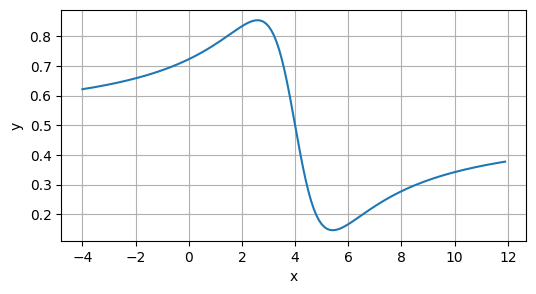

In [37]:
import math
import functools
import numpy as np
import matplotlib.pyplot as plt

# Question 1.3 Plot P(w_1 | x) given a_1, a_2, b

def Cauchy_dist(x, a, b):
    denom = 1 + ((x - a) / b) ** 2

    return 1 / (np.pi * b * denom)

def plot_fig(fn, figsize=(6, 3), xx=None, means=None, reverse=False):
    xx = np.arange(-4, 12, 0.1) if xx is None else xx
    yy = fn(xx)
    if reverse:
        xx, yy = yy, xx
    plt.figure(figsize=figsize)
    if means:
        x, y = zip(*means)
        if reverse:
            x, y = y, x
        plt.plot(x, y, 'o')
    plt.grid(visible=True)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.plot(xx, yy)
    plt.show()

a_1 = 3
a_2 = 5
b = 1

w_1 = functools.partial(Cauchy_dist, a=a_1, b=b)
w_2 = functools.partial(Cauchy_dist, a=a_2, b=b)
p = lambda x: w_1(x) / (w_1(x) + w_2(x))
plot_fig(p)

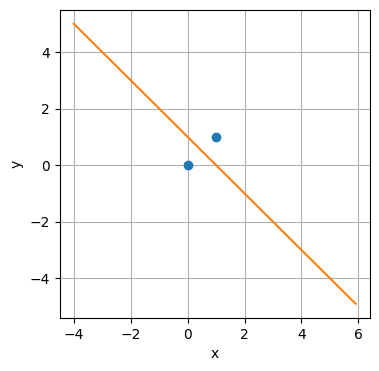

In [40]:
# Question 2.1 x + y + 1 = 0
y = lambda x: -x + 1
means = [(0, 0), (1, 1)]
plot_fig(y, figsize=(4, 4), xx=np.arange(-4, 6, 0.1), means=means)

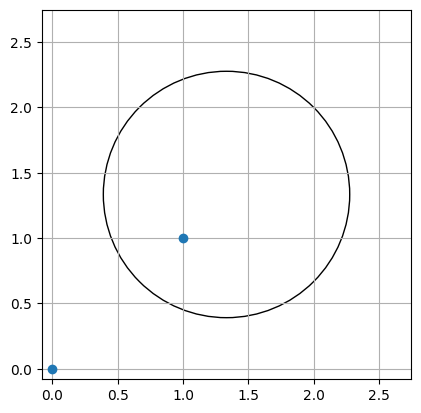

In [ ]:
# Question 2.2


def plot_circ(a, b, r, means=None):
    fig, ax = plt.subplots()
    circle = plt.Circle((a, b), r, fill=False)
    ax.add_patch(circle)
    if means:
        x, y = zip(*means)
        plt.plot(x, y, 'o')
    ax.set_aspect('equal')
    plt.grid(True)
    ax.set_xlim(a - r - 0.5 * r, a + r + 0.5 * r)
    ax.set_ylim(b - r - 0.5 * r, b + r + 0.5 * r)
    plt.show()

a = 4 / 3
b = 4 / 3
r = 2 * np.sqrt(2) / 3
plot_circ(a, b, r, means=means)

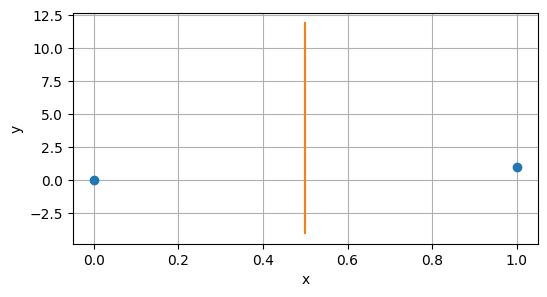

In [ ]:
# Question 2.3

y = lambda x: np.array([0.5] * len(x))
plot_fig(y, means=means, reverse=True)

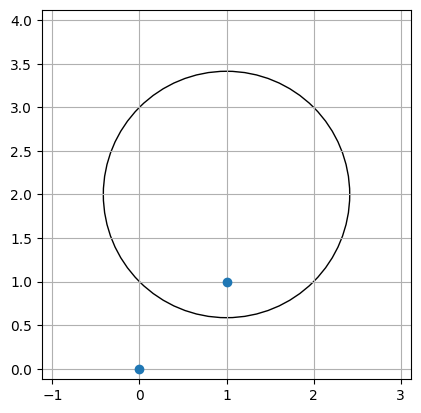

In [ ]:
# Question 2.4

a = 1
b = 2
r = np.sqrt(2)
plot_circ(a, b, r, means)

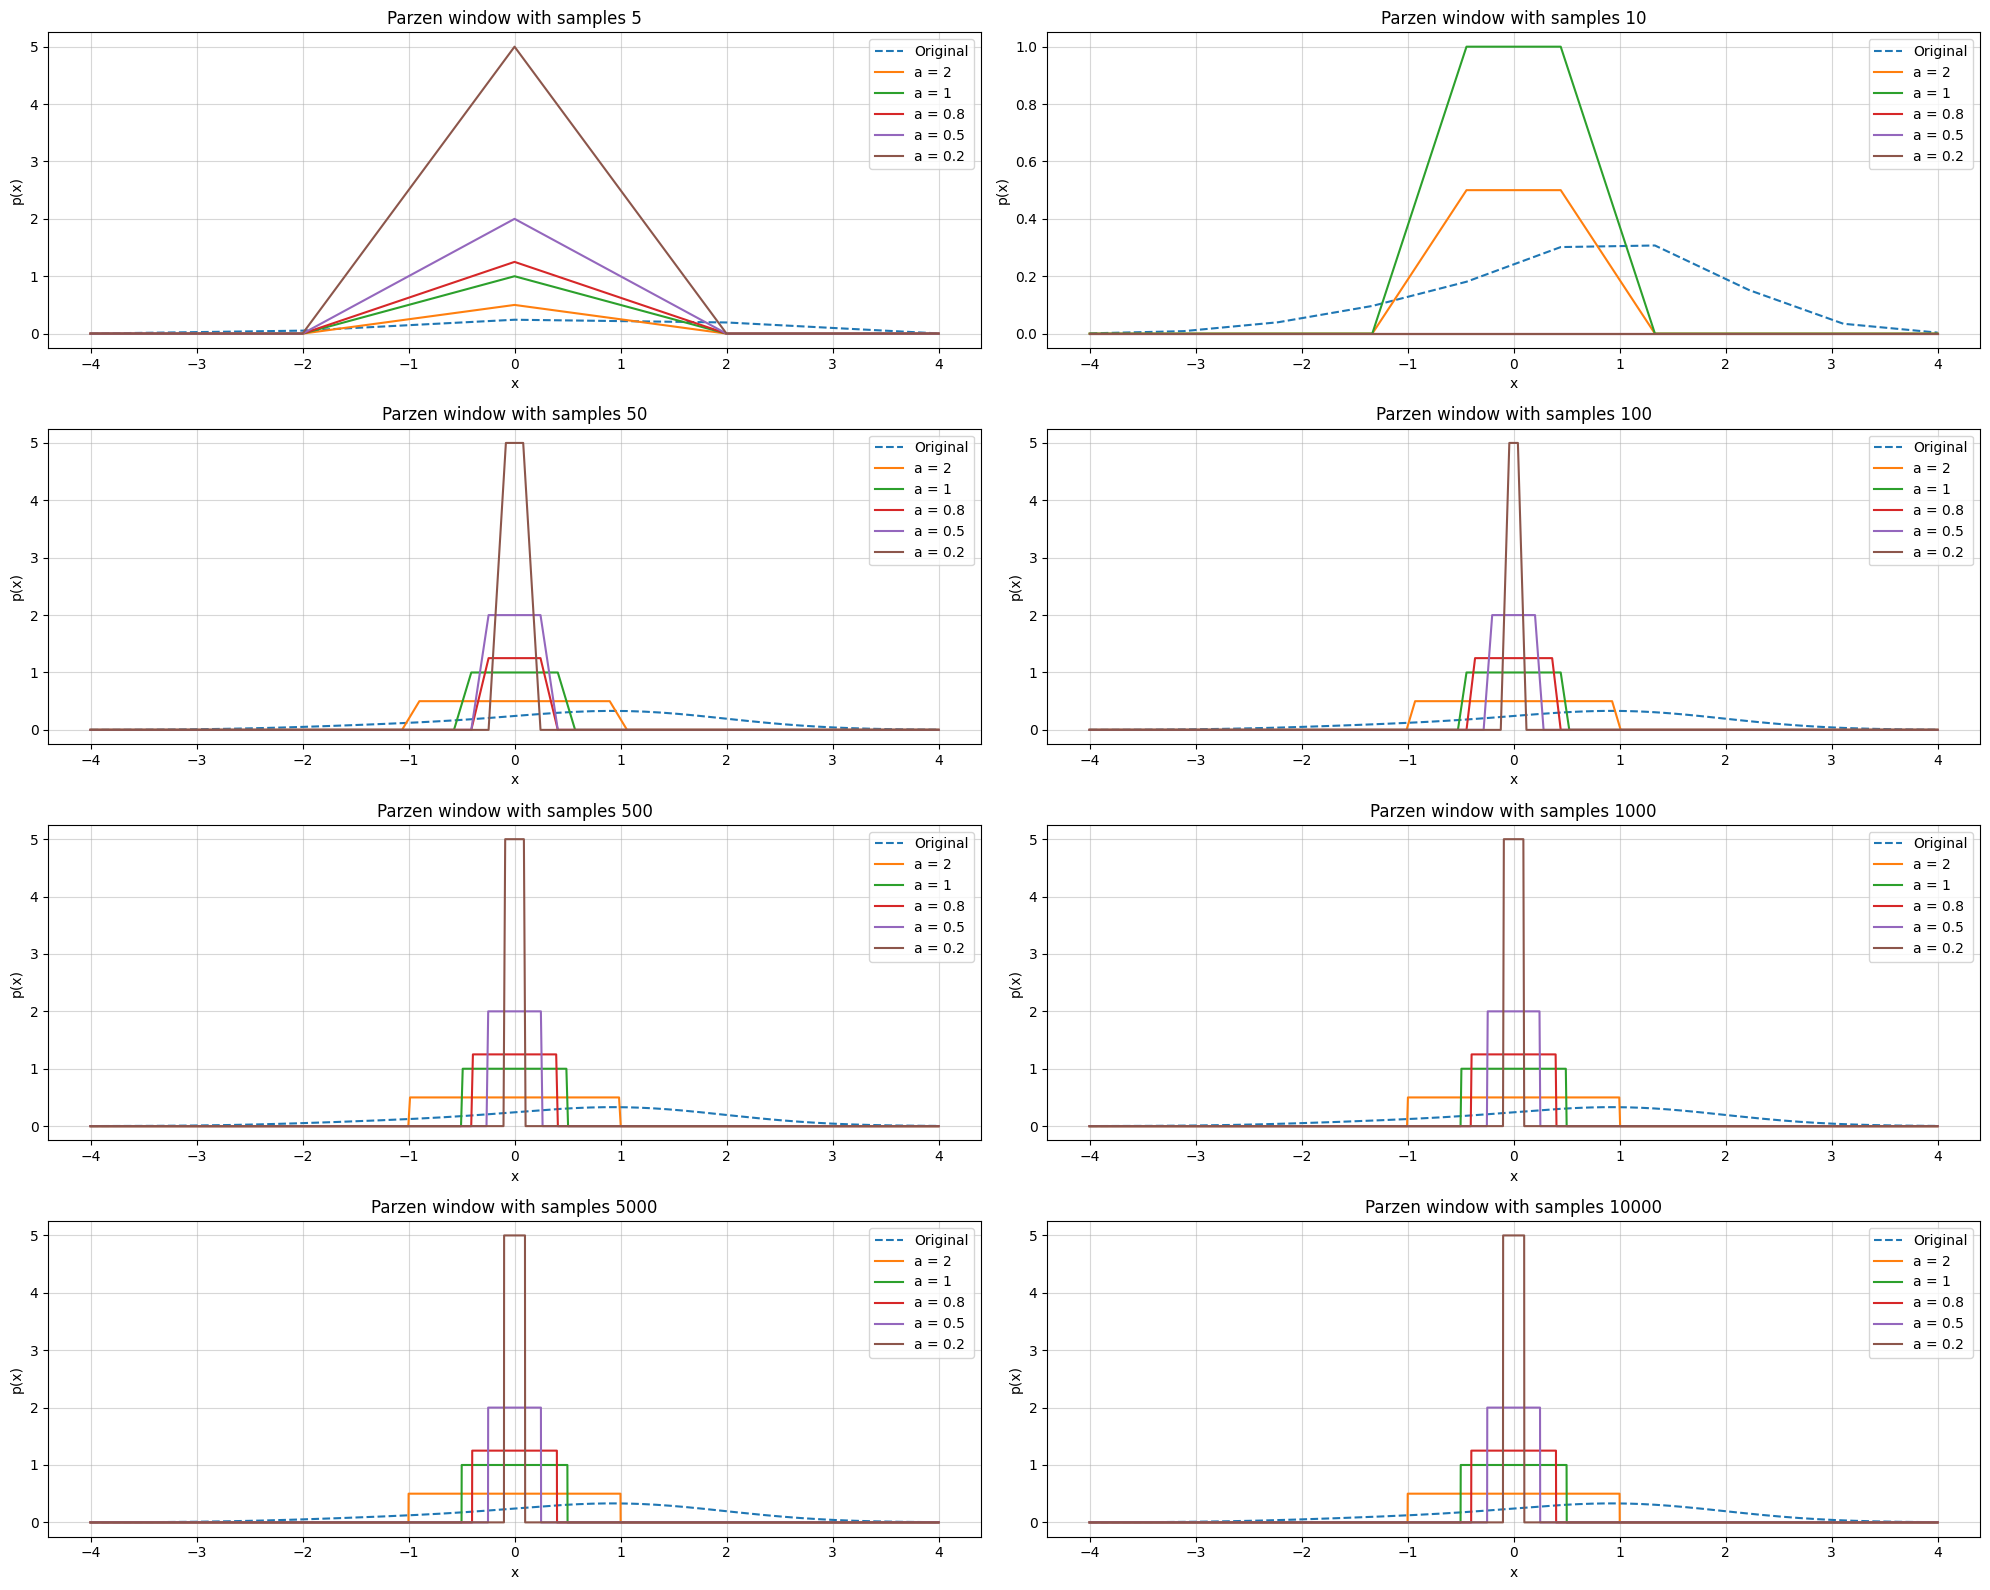

In [39]:
# Question 4.1
import numpy as np
import matplotlib.pyplot as plt
import functools
from scipy.stats import norm

def window_fn(x, a):
    return np.where(np.abs(x) <= a / 2, 1 / a, 0)

def org_fn(x):
    return 0.2 * norm.pdf(x, loc=-1, scale=1) + 0.8 * norm.pdf(x, loc=1, scale=1)

def plot_fig_with_org(fns, org_fn, ax=None, figsize=(6, 3), xx=None, window_width=None, title=None):
    if not isinstance(fns, list):
        fns = [fns]
    if not isinstance(window_width, list):
        window_width = [window_width] * len(fns)
    
    xx = np.arange(-10, 10, 0.1) if xx is None else xx
    org_yy = org_fn(xx)
    if ax is not None:
        ax.plot(xx, org_yy, label='Original', linestyle='--')
        for idx, fn in enumerate(fns):
            yy = fn(xx)
            label = f"Estimated {idx + 1}" if window_width is None \
                else f"a = {window_width[idx]}"
            ax.plot(xx, yy, label=label)

        ax.grid(visible=True, alpha=0.5)
        ax.set_xlabel('x')
        ax.set_ylabel('p(x)')
        ax.set_title(title if title else "Estimated vs Original")
        ax.legend()
    else:
        plt.figure(figsize=figsize)
        plt.plot(xx, org_yy, label='Original', linestyle='--')

        for idx, fn in enumerate(fns):
            yy = fn(xx)
            label = f"Estimated {idx + 1}" if window_width is None \
                else f"Estimated with a = {window_width[idx]}."
            plt.plot(xx, yy, label=label)

        plt.grid(visible=True, alpha=0.5)
        plt.xlabel('x')
        plt.ylabel('p(x)')
        # plt.ylim(0, max(org_yy) * 1.5)
        plt.title(title if title else "Estimated vs Original Dist")
        plt.legend()
        plt.show()

def plot_multi_figs(fn, org_fn, num_samples, window_widths, cols=2, title=None):
    num_ns = len(num_samples)
    assert num_ns % cols == 0
    rows = num_ns // cols
    fns = [functools.partial(fn, a=w) for w in window_widths]
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 4))
    if num_ns == 1:
        axes = [axes]
    
    axes = axes.flatten()
    for idx, n in enumerate(num_samples):
        xx = np.linspace(-4, 4, n)
        plot_fig_with_org(
            fns=fns,
            ax=axes[idx],
            xx=xx,
            org_fn=org_fn,
            window_width=window_widths,
            title=f"{title} with samples {n}"
        )
    
    plt.tight_layout()
    plt.show()

num_samples = [5, 10, 50, 100, 500, 1000, 5000, 10000]
window_widths = [2, 1, 0.8, 0.5, 0.2]
# fns = [functools.partial(window_fn, a=w) for w in window_widths]
# for n in num_samples:
#     xx = np.linspace(-4, 4, n)
#     plot_fig_with_org(fns, org_fn, figsize=(10, 4), xx=xx, window_width=window_widths, title=f"Parzen window with samples {n}")

plot_multi_figs(window_fn, org_fn, num_samples, window_widths, title="Parzen window")

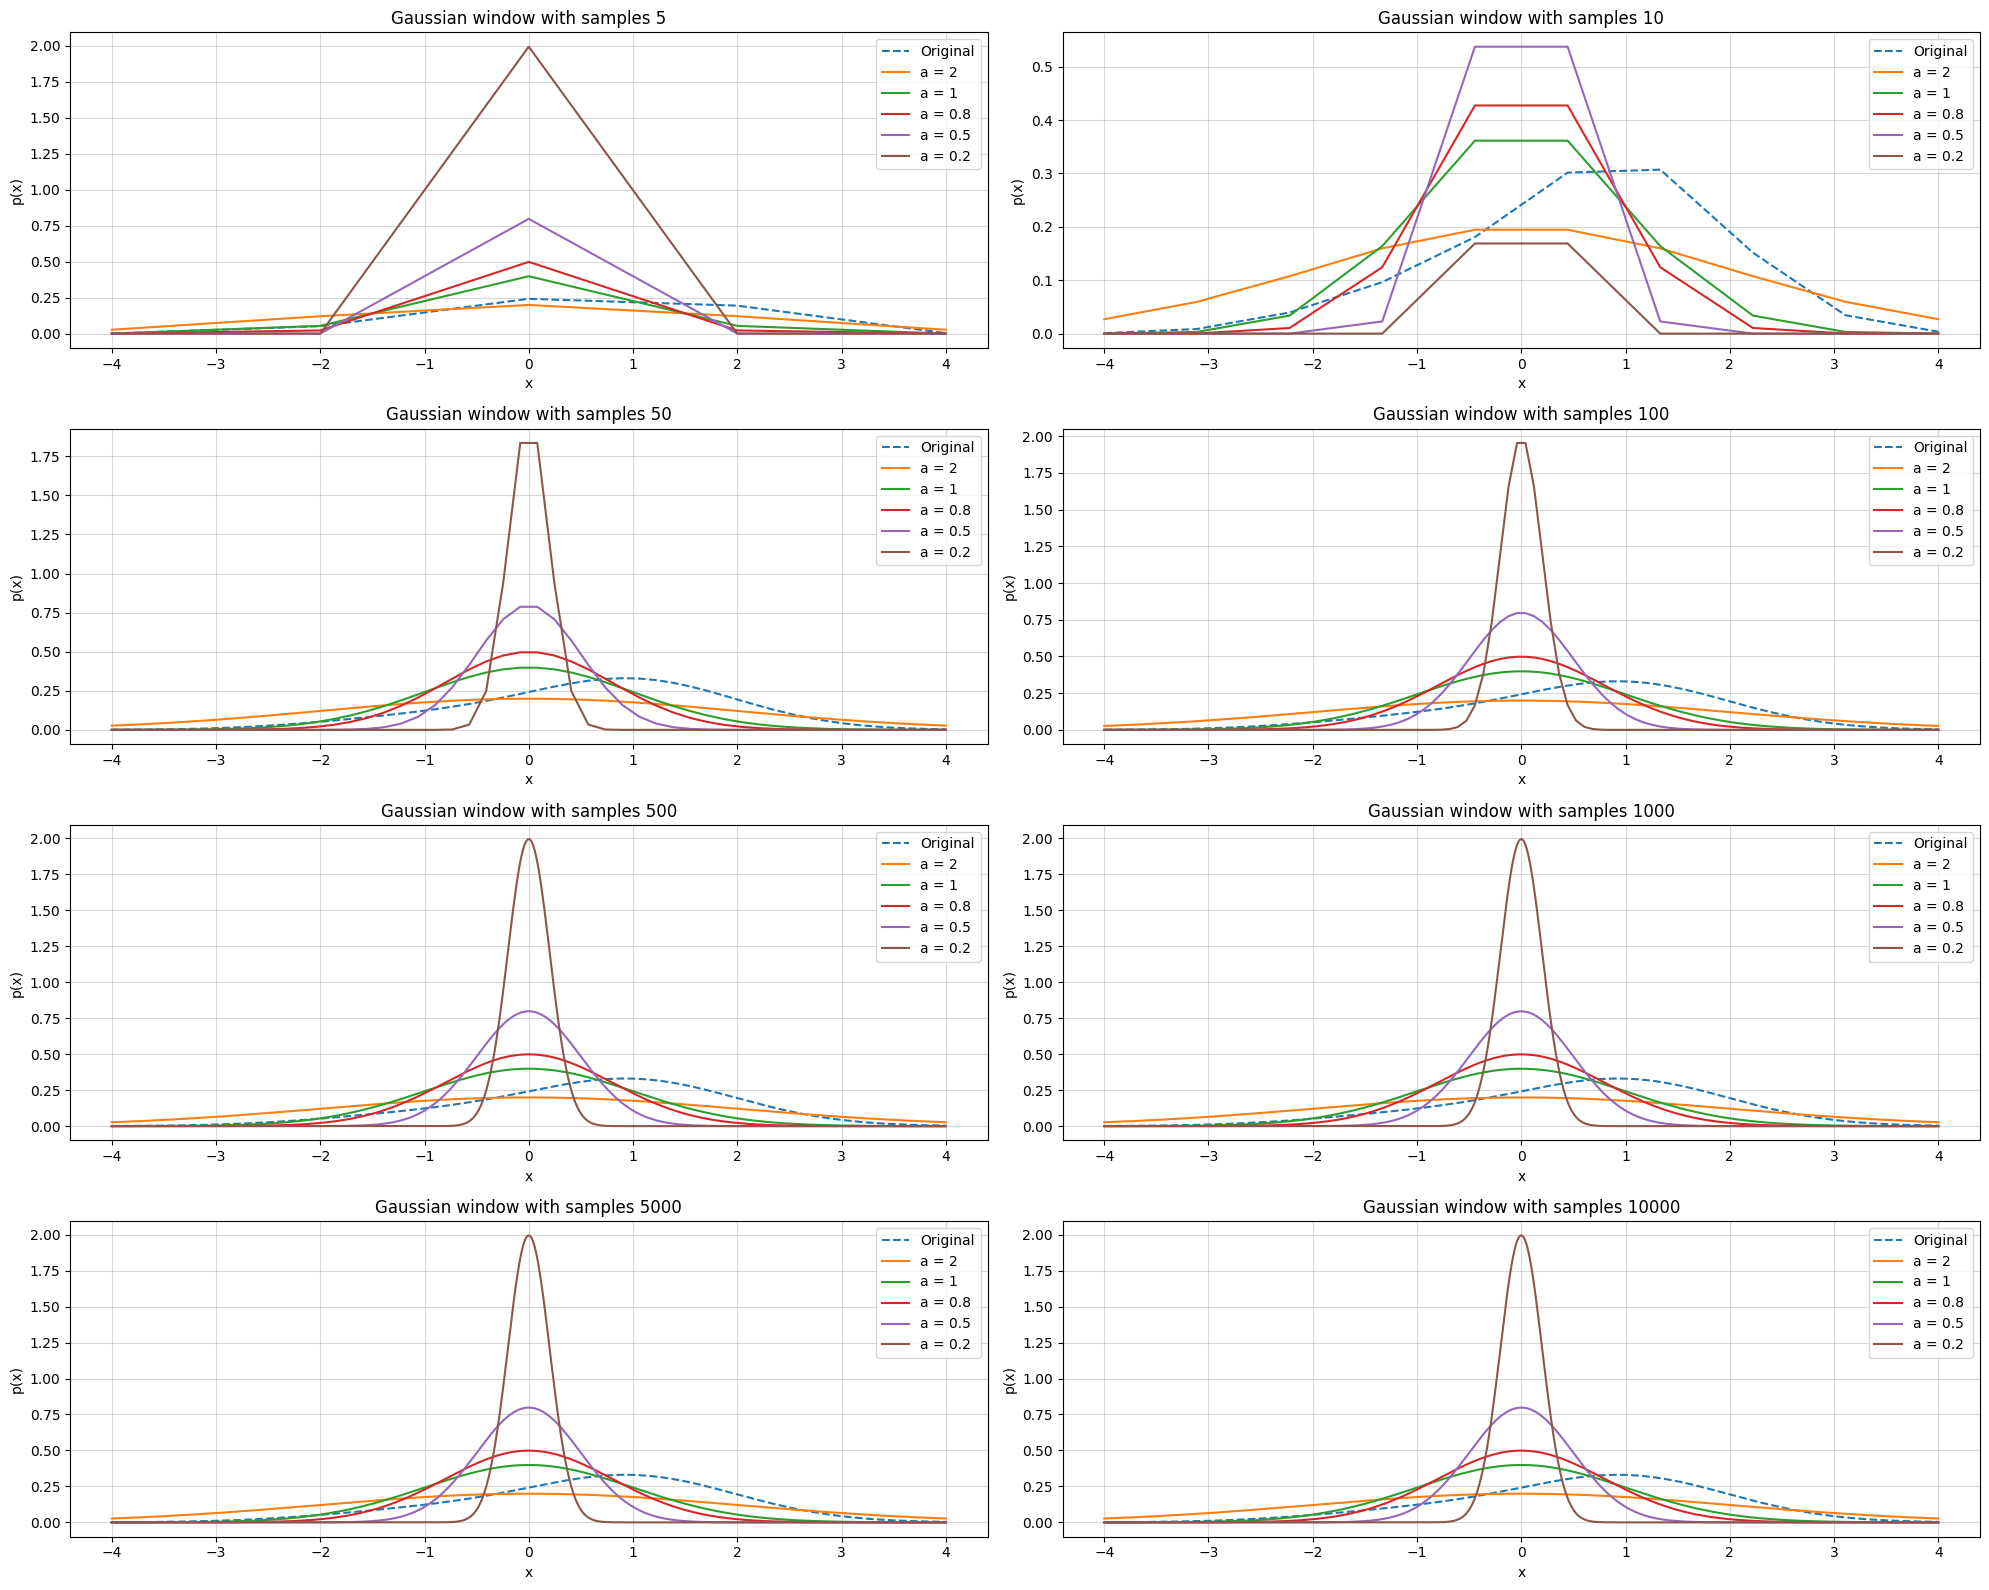

In [40]:
def gaussian_window_fn(x, a):
    factor = 1 / (a * np.sqrt(2 * np.pi))

    return factor * np.exp(-0.5 * x ** 2 / a ** 2)

# gauss_fns = [functools.partial(gaussian_window_fn, a=w) for w in window_widths]
# for n in num_samples:
#     xx = np.linspace(-4, 4, n)
#     plot_fig_with_org(gauss_fns, org_fn, figsize=(10, 4), xx=xx, window_width=window_widths, title=f"Gaussian window with samples {n}")
plot_multi_figs(gaussian_window_fn, org_fn, num_samples, window_widths, title="Gaussian window")

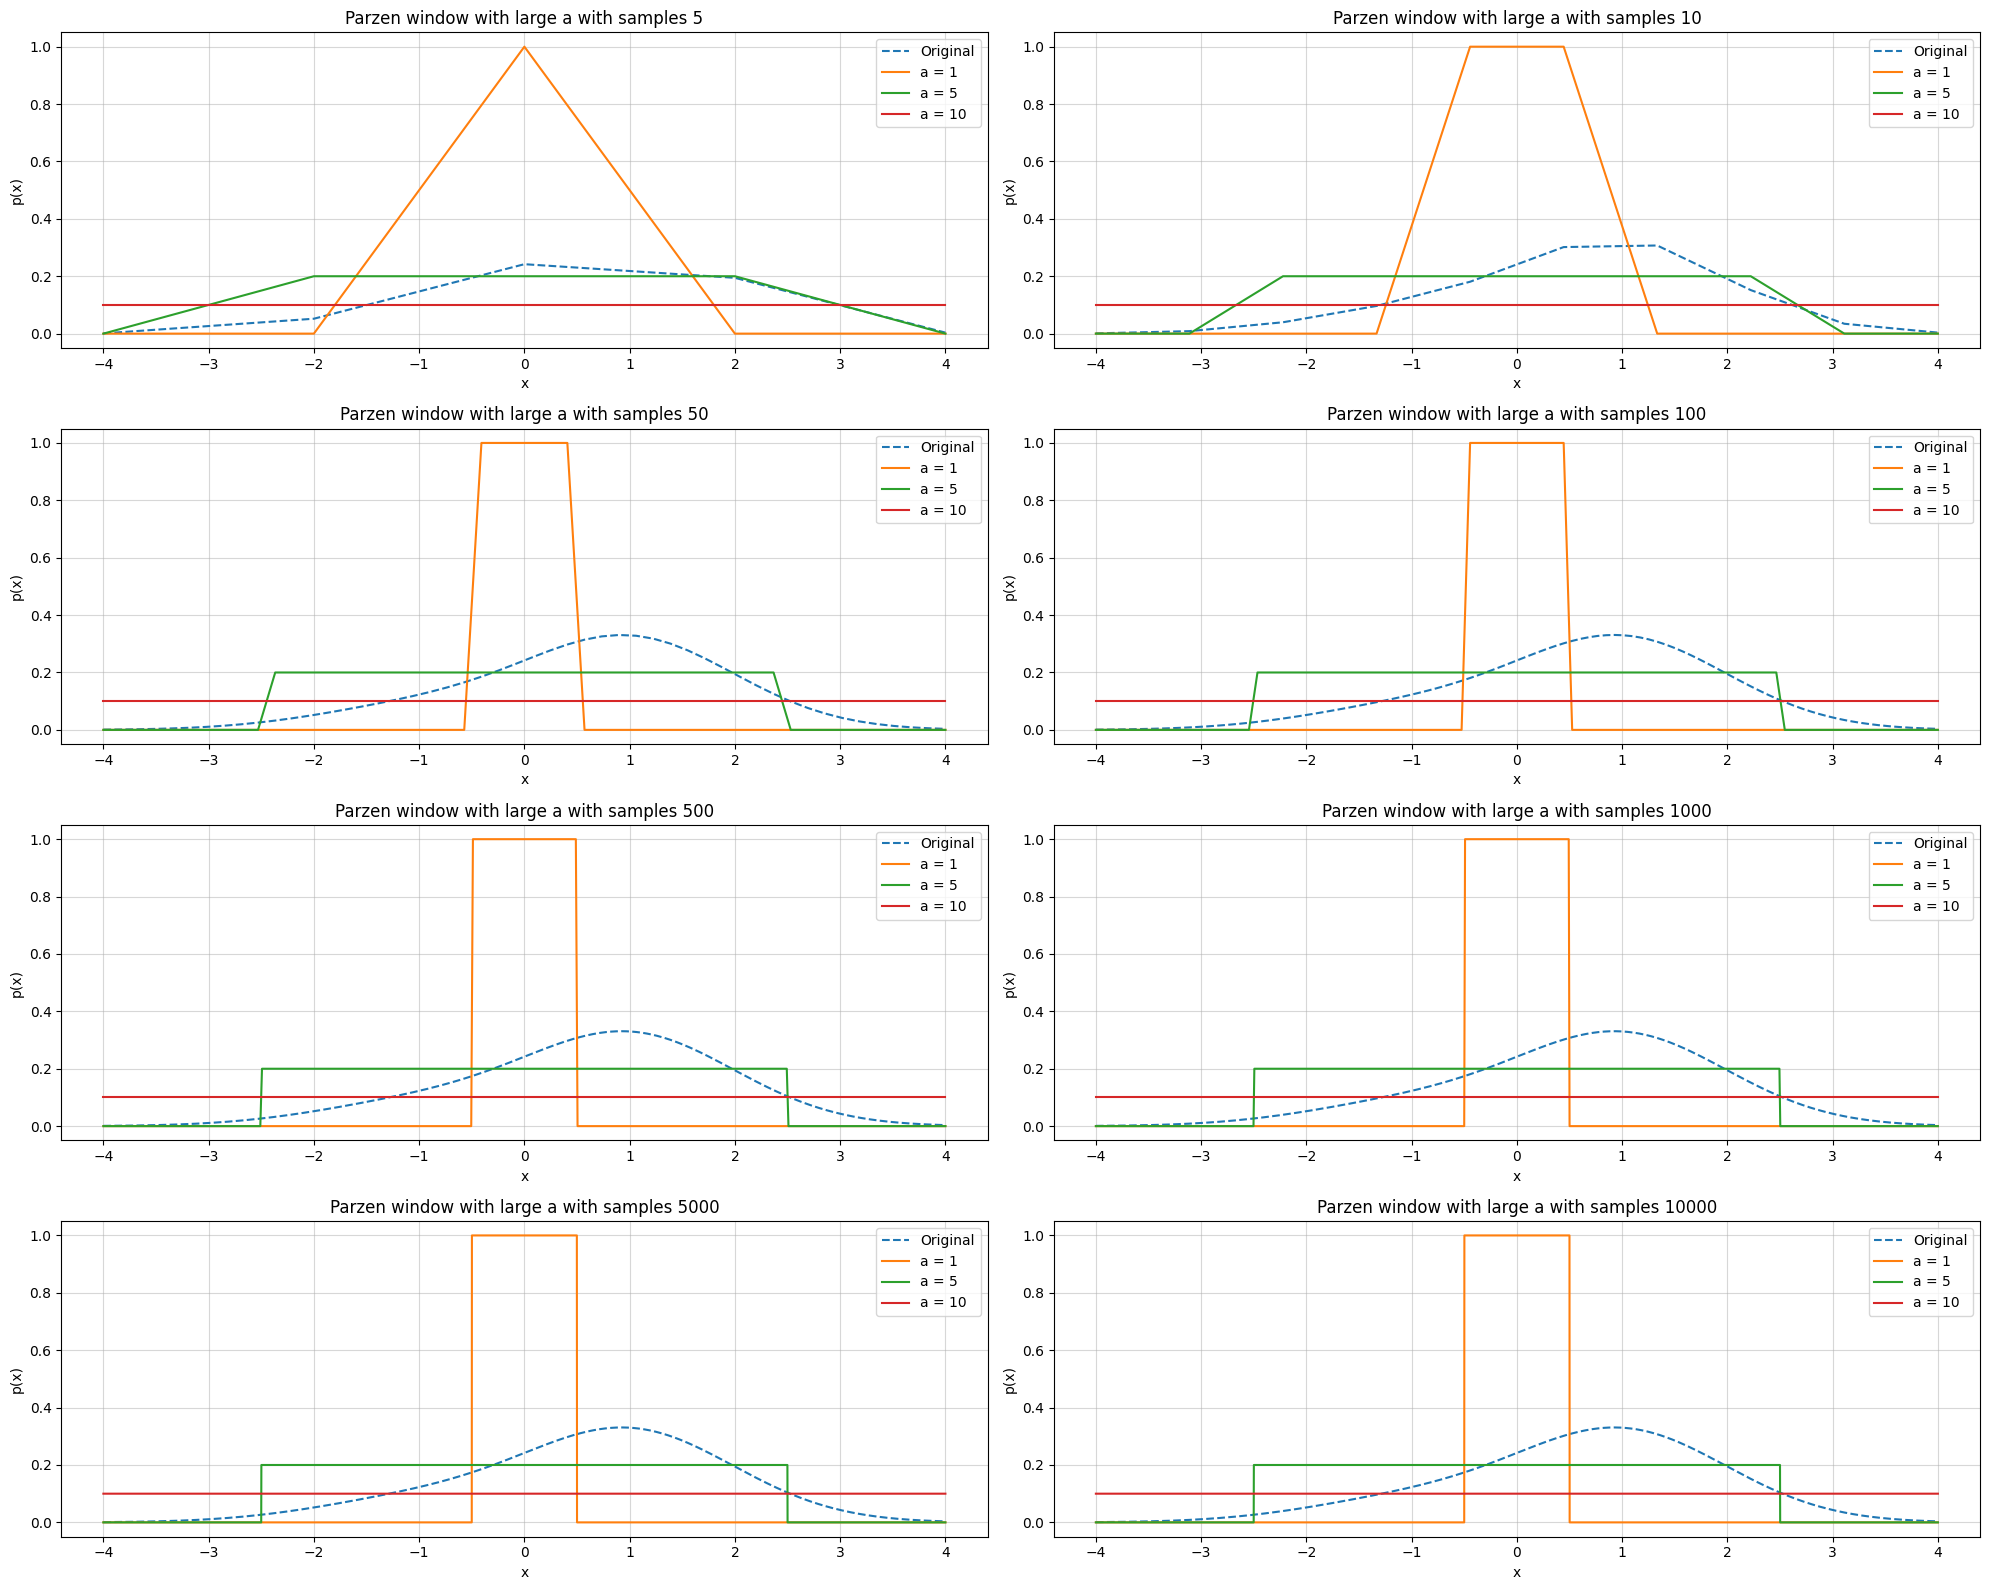

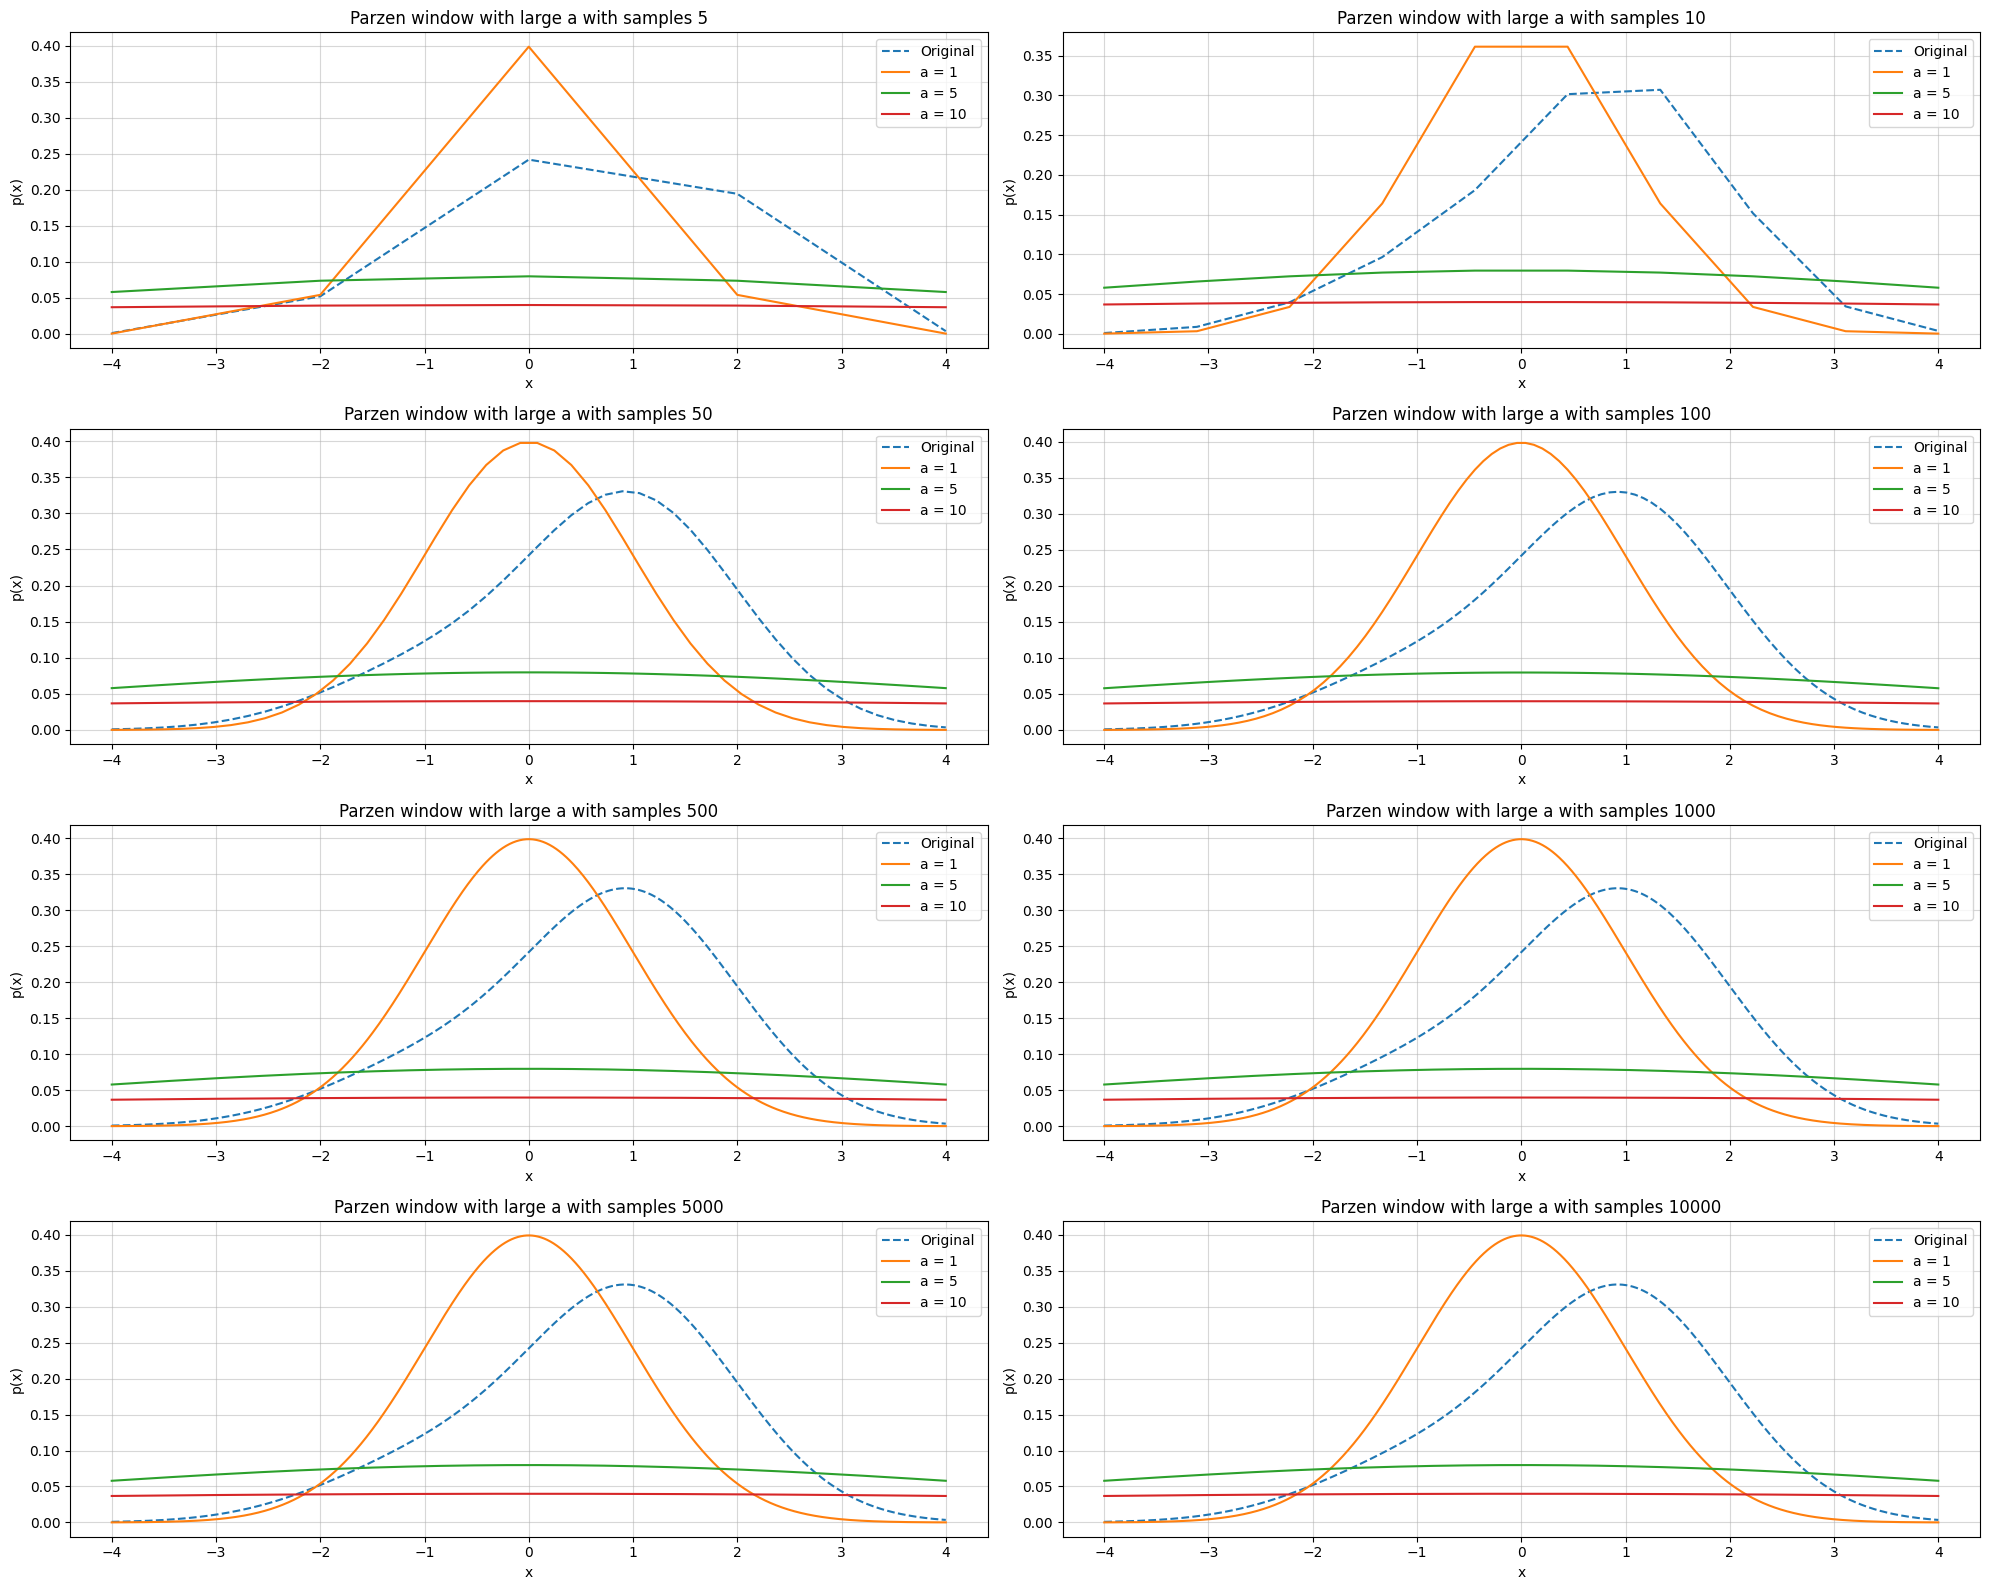

In [41]:
large_window_widths = [1, 5, 10]
plot_multi_figs(window_fn, org_fn, num_samples, large_window_widths, title="Parzen window with large a")
plot_multi_figs(gaussian_window_fn, org_fn, num_samples, large_window_widths, title="Parzen window with large a")
# n_fns = [functools.partial(window_fn, a=w) for w in large_window_widths]
# n_gauss_fns = [functools.partial(gaussian_window_fn, a=w) for w in large_window_widths]
# for n in num_samples:
#     xx = np.linspace(-4, 4, n)
#     plot_fig_with_org(n_fns, org_fn, figsize=(10, 4), xx=xx, window_width=large_window_widths, title=f"Parzen window with samples {n}")
#     plot_fig_with_org(n_gauss_fns, org_fn, figsize=(10, 4), xx=xx, window_width=large_window_widths, title=f"Gaussian window with samples {n}")